In [581]:
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot  as plt
import seaborn as sns

In [582]:
df=pd.read_csv("synthetic_ecommerce_order_risk_dataset.csv")

In [583]:
df

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,2025-11-26,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0,Normal
2,ORD-2023-001721,2023-11-07,Netherlands,Mobile,Organic Search,Debit Card,Garden,324,2,102.67,55.49,1,0.05,175.1,5,0,0,0,0,3.3,0,0,Normal
3,ORD-2024-009121,2024-05-28,Netherlands,Mobile,Organic Search,Klarna,Electronics,378,3,72.71,112.54,5,0.22,271.4,3,0,0,0,0,4.2,1,0,Return Risk
4,ORD-2025-000361,2025-01-31,Netherlands,Desktop,Direct,Bank Transfer,Home & Kitchen,447,5,52.26,55.32,8,0.25,285.3,3,0,1,0,0,5.0,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,ORD-2023-011965,2023-02-19,France,Mobile,Social Media,Credit Card,Garden,742,3,25.75,25.75,1,0.31,121.4,3,0,0,0,1,4.5,0,0,Normal
11996,ORD-2023-005192,2023-05-12,France,Mobile,Organic Search,Debit Card,Fashion,152,1,96.29,118.35,2,0.09,225.5,4,0,0,0,0,5.0,0,0,Normal
11997,ORD-2024-005391,2024-06-13,Germany,Mobile,Organic Search,Credit Card,Fashion,130,0,114.14,114.13,1,0.08,669.6,5,0,0,0,0,4.5,0,0,Normal
11998,ORD-2025-000861,2025-04-04,Poland,Desktop,Marketplace,PayPal,Fashion,203,1,21.60,25.58,1,0.23,229.4,5,0,0,0,0,4.4,0,0,Normal


In [584]:
df.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

In [585]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

li=LabelEncoder()
df["risk_label"]=li.fit_transform(df["risk_label"])


In [586]:
for col in ["traffic_source", "product_category","payment_method","country","device_type"]:
    print(col)
    print(df[col].unique())

traffic_source
['Paid Ads' 'Email' 'Organic Search' 'Direct' 'Social Media' 'Marketplace']
product_category
['Sports' 'Garden' 'Electronics' 'Home & Kitchen' 'Pet Supplies' 'Beauty'
 'Toys' 'Fashion']
payment_method
['Credit Card' 'Debit Card' 'Klarna' 'Bank Transfer' 'PayPal' 'Gift Card']
country
['Belgium' 'Netherlands' 'Italy' 'Germany' 'Turkey' 'France' 'Spain'
 'Poland']
device_type
['Mobile' 'Desktop' 'Tablet']


In [587]:
df=pd.get_dummies(df,columns=[ 
    "traffic_source",
    "product_category",
        "payment_method",])

<Axes: >

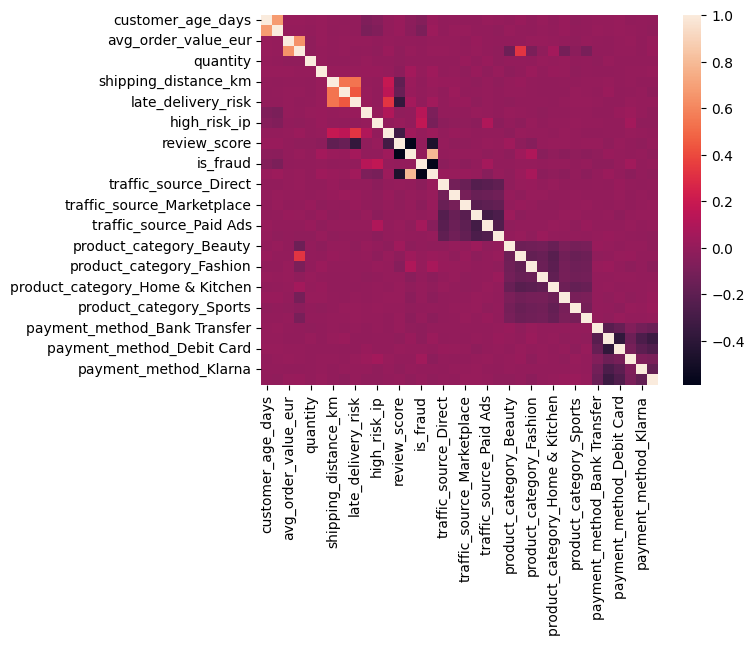

In [588]:
sns.heatmap(df.corr(numeric_only=True))

In [589]:
df=df.drop(columns=["quantity",
                    "order_id",
                    "discount_rate",
                    "review_score",
                    "order_date",
                    "country",
                    "device_type"])

In [590]:
df

,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,is_returned,is_fraud,risk_label,traffic_source_Direct,traffic_source_Email,traffic_source_Marketplace,traffic_source_Organic Search,traffic_source_Paid Ads,traffic_source_Social Media,product_category_Beauty,product_category_Electronics,product_category_Fashion,product_category_Garden,product_category_Home & Kitchen,product_category_Pet Supplies,product_category_Sports,product_category_Toys,payment_method_Bank Transfer,payment_method_Credit Card,payment_method_Debit Card,payment_method_Gift Card,payment_method_Klarna,payment_method_PayPal
0,381,3,28.66,33.71,105.7,5,0,0,0,0,0,0,1,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
1,561,6,41.93,73.29,528.2,4,0,0,0,0,0,0,1,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
2,324,2,102.67,55.49,175.1,5,0,0,0,0,0,0,1,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
3,378,3,72.71,112.54,271.4,3,0,0,0,0,1,0,2,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,447,5,52.26,55.32,285.3,3,0,1,0,0,0,0,1,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,742,3,25.75,25.75,121.4,3,0,0,0,1,0,0,1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False
11996,152,1,96.29,118.35,225.5,4,0,0,0,0,0,0,1,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
11997,130,0,114.14,114.13,669.6,5,0,0,0,0,0,0,1,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
11998,203,1,21.60,25.58,229.4,5,0,0,0,0,0,0,1,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True


In [591]:
df.columns

Index(['customer_age_days', 'previous_orders', 'avg_order_value_eur',
       'order_value_eur', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'is_returned', 'is_fraud', 'risk_label',
       'traffic_source_Direct', 'traffic_source_Email',
       'traffic_source_Marketplace', 'traffic_source_Organic Search',
       'traffic_source_Paid Ads', 'traffic_source_Social Media',
       'product_category_Beauty', 'product_category_Electronics',
       'product_category_Fashion', 'product_category_Garden',
       'product_category_Home & Kitchen', 'product_category_Pet Supplies',
       'product_category_Sports', 'product_category_Toys',
       'payment_method_Bank Transfer', 'payment_method_Credit Card',
       'payment_method_Debit Card', 'payment_method_Gift Card',
       'payment_method_Klarna', 'payment_method_PayPal'],
      dtype='object')

In [592]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
x=df.drop(columns=["is_fraud"])
y=df["is_fraud"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



In [593]:
num_cols = df.select_dtypes(include="number").columns.tolist()


for col in num_cols:
    print(col)
    print(df[col].unique())

customer_age_days
[ 381  561  324 ... 1027  823  979]
previous_orders
[ 3  6  2  5  1  0  4  7  9  8 12 10 13 11]
avg_order_value_eur
[ 28.66  41.93 102.67 ...  65.5   96.29 114.14]
order_value_eur
[ 33.71  73.29  55.49 ...  28.75 118.35 114.13]
shipping_distance_km
[105.7 528.2 175.1 ... 734.9 249.5 406.6]
delivery_days_estimated
[5 4 3 6 2 7 1 8 9]
late_delivery_risk
[0 1]
address_mismatch
[0 1]
high_risk_ip
[0 1]
customer_support_contacts
[0 1 2 3 4 5]
is_returned
[0 1]
is_fraud
[0 1]
risk_label
[1 2 0]


In [594]:
scaler=[
   'customer_age_days',
    "avg_order_value_eur",
    "shipping_distance_km",	
    "delivery_days_estimated",
    "previous_orders",
    "order_value_eur",
    "customer_support_contacts"   
]
sc=StandardScaler()
df[scaler]=sc.fit_transform(df[scaler])

    

In [595]:
df

,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,is_returned,is_fraud,risk_label,traffic_source_Direct,traffic_source_Email,traffic_source_Marketplace,traffic_source_Organic Search,traffic_source_Paid Ads,traffic_source_Social Media,product_category_Beauty,product_category_Electronics,product_category_Fashion,product_category_Garden,product_category_Home & Kitchen,product_category_Pet Supplies,product_category_Sports,product_category_Toys,payment_method_Bank Transfer,payment_method_Credit Card,payment_method_Debit Card,payment_method_Gift Card,payment_method_Klarna,payment_method_PayPal
0,0.118760,0.555363,-0.706244,-0.492335,-1.130809,0.851454,0,0,0,-0.419118,0,0,1,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
1,0.876507,2.132226,-0.244127,0.220329,0.148364,-0.053305,0,0,0,-0.419118,0,0,1,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
2,-0.121194,0.029741,1.871094,-0.100172,-0.920692,0.851454,0,0,0,-0.419118,0,0,1,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
3,0.106131,0.555363,0.827761,0.927051,-0.629131,-0.958065,0,0,0,-0.419118,1,0,2,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,0.396600,1.606605,0.115607,-0.103233,-0.587047,-0.958065,0,1,0,-0.419118,0,0,1,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,1.638464,0.555363,-0.807583,-0.635660,-1.083275,-0.958065,0,0,0,1.669512,0,0,1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False
11996,-0.845263,-0.495880,1.648916,1.031664,-0.768099,-0.053305,0,0,0,-0.419118,0,0,1,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
11997,-0.937877,-1.021501,2.270528,0.955680,0.576471,0.851454,0,0,0,-0.419118,0,0,1,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
11998,-0.630568,-0.495880,-0.952103,-0.638721,-0.756291,0.851454,0,0,0,-0.419118,0,0,1,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True


In [596]:
print(df["is_fraud"].value_counts())

is_fraud
0    11553
1      447
Name: count, dtype: int64


In [597]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [598]:
models = [
    ("lg", LogisticRegression(
        max_iter=5000
    )),
    
    ("svm", SVC()),
    
    ("tree", DecisionTreeClassifier()),
    
    ("bayes", GaussianNB()),
    
    ("knn", KNeighborsClassifier())
]

In [599]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

for name, model in models:

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    acc = accuracy_score(y_test, pred)

    print(name, acc)
    print(classification_report(y_test, pred))

lg 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2316
           1       1.00      1.00      1.00        84

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400

svm 0.965
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2316
           1       0.00      0.00      0.00        84

    accuracy                           0.96      2400
   macro avg       0.48      0.50      0.49      2400
weighted avg       0.93      0.96      0.95      2400

tree 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2316
           1       1.00      1.00      1.00        84

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00     

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag